In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 5: k-nearest neighbor regressor

The knn algorithm can be also used for regression. 
The output is computed based on the average of the $y$ values of its nearest neighbors.

## Part 1 

Implement the knn algorithm for regression. Hint: the function `numpy.average` ([reference page](https://numpy.org/doc/stable/reference/generated/numpy.average.html#numpy.average)) can compute weighted averages. 

In [39]:
def knn_regressor(X,y,X_new,k,weights='uniform'):
    
    # in these lines, we extract the number of columns as the number of points
    # in our original and new data. implies we need to input column vectors for 1D data
    
    m= X.shape[0]
    m_new = X_new.shape[0]
    
    dist = np.sqrt(np.sum(X_new**2,axis=1)[:,None]+np.sum(X**2,axis=1)[None,:]-2*X_new.dot(X.T))
    
    knn = np.argsort(dist,axis=1)[:,0:k]
    
    y_pred = np.zeros(m_new)
    
    for i in range(m_new):
        
        nearest_outputs = y[knn[i]]
    
        if weights=='uniform':
            w = np.ones(k)
        elif weights=='distance':
            w=1/dist[i,knn[i]]
        else:
            print('weights not recognized: should be uniform or distance')
            return 
        
        #prediction
        y_pred[i] = np.average(nearest_outputs,weights=w)
    
    return y_pred

## Part 2

Consider the following data points

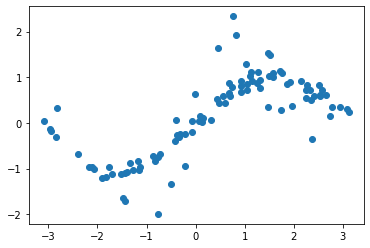

In [5]:
x = -np.pi + 2*np.pi*np.random.rand(100)
y = np.sin(x) + 0.1*np.random.randn(100) # y = sin(x) + random noise
x = x.reshape(-1,1) # reshape x as a column vector
y[::5] += 3 * (0.5 - np.random.rand(20)) # add outliers
plt.scatter(x,y)

Fit and plot a knn regressor with $k=1$.

In [28]:
my_array = np.asarray([[-3 + i*0.1 for i in range(60)]])

my_array.shape

(1, 60)

In [36]:
m = 70

x_plot = np.asarray([[-3.5 + i*0.1 for i in range(m)]]) # normally i would use linspace but dimensions were weird

x_plot = x_plot.T
#x_plot.reshape(1,m) # need column vector to correctly extract dimension in function
#x_plot.flatten()
#x_plot.shape

k=1

y_plot = knn_regressor(x,y,x_plot,k,weights='uniform')

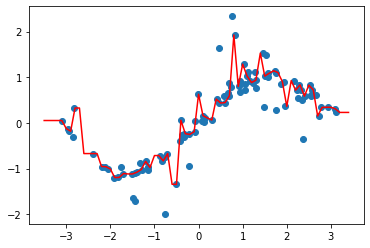

In [37]:
plt.scatter(x,y)
plt.plot(x_plot,y_plot, color='red')

Fit and plot a knn regressor with $k=10$.

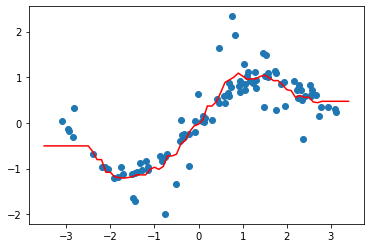

In [38]:
k=10

y_plot = knn_regressor(x,y,x_plot,k,weights='uniform')
plt.scatter(x,y)
plt.plot(x_plot,y_plot, color='red')